# Eksperimen 11 — 5-Fold Cross Validation (V2 Per-Frame)

Notebook ini digunakan untuk mengevaluasi performa model `AttentiveSkel3DPerFrame` menggunakan **Stratified 5-Fold Cross Validation (K = 5)** murni pada tingkat per-frame.

---

## Protokol Eksperimen

- Menggunakan **Stratified K-Fold (K = 5)**. Mengingat label V2 berjumlah 64 per video, stratifikasi pembagian lipatan (fold) dihitung berdasarkan label global dari dataset V1 (`dataset_manifest.csv`) untuk menjamin proporsi jumlah video gerakan salah/benar tersebar seimbang.
- Pelatihan (training) sesungguhnya **tetap menggunakan label frame 64 dimensi** dari `manifest_v2.csv`.
- Model dan Optimizer diinisialisasi ulang dari nol (*from scratch*) pada setiap awal fold (bobot tidak diwariskan).
- Metrik utama yang dicatat adalah **Best Validation Accuracy** (dihitung per-frame) berdasarkan nilai *validation loss* terendah.
- Optimizer menggunakan **Adam** (`learning rate = 1e-3`, `weight_decay = 1e-4`).
- Learning rate dikontrol menggunakan scheduler **ReduceLROnPlateau**.
- **Transformasi Tensor Mutlak:** Output `(Batch, 64, 2)` dan label `(Batch, 64)` di-flatten menggunakan `.view(-1, 2)` dan `.view(-1)` sebelum perhitungan Loss.


### 1. Setup dan Import Library

In [13]:
# ============================================================
# Import library yang dibutuhkan
# ============================================================
import sys
import time
from pathlib import Path
import copy

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, SubsetRandomSampler
from sklearn.model_selection import StratifiedKFold

# Tambahkan direktori root proyek ke Python path
project_root = Path.cwd().parent.parent
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

# Import model V2 dan Class Dataset mentah
from src.models.v2.model_per_frame import AttentiveSkel3DPerFrame
from src.data.v2.dataset import PerFrameDataset

# Tentukan device
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Import berhasil.")
print(f"PyTorch versi : {torch.__version__}")
print(f"Device aktif  : {DEVICE}")

Import berhasil.
PyTorch versi : 2.5.1
Device aktif  : cuda


### 2. Definisi Skenario Ablasi

In [14]:
# ============================================================
# Menyusun 5 Skenario Arsitektur untuk V2
# ============================================================
scenarios = [
    {"name": "Baseline 3D-CNN", "prior": False, "learned": False, "temporal": False},
    {"name": "Ablasi A — Tanpa Prior", "prior": False, "learned": True, "temporal": True},
    {"name": "Ablasi B — Tanpa Learned Spatial", "prior": True, "learned": False, "temporal": True},
    {"name": "Ablasi C — Tanpa Temporal", "prior": True, "learned": True, "temporal": False},
    {"name": "Full AttentiveSkel-3D", "prior": True, "learned": True, "temporal": True}
]

print("Skenario yang akan dievaluasi:")
for idx, s in enumerate(scenarios, 1):
    print(f"{idx}. {s['name']}")

Skenario yang akan dievaluasi:
1. Baseline 3D-CNN
2. Ablasi A — Tanpa Prior
3. Ablasi B — Tanpa Learned Spatial
4. Ablasi C — Tanpa Temporal
5. Full AttentiveSkel-3D


### 3. Persiapan Dataset & Stratifikasi

In [15]:
# ============================================================
# Membaca label global dari dataset_manifest.csv (V1)
# semata-mata untuk memandu StratifiedKFold agar porsi video
# gerakan salah dan benar seimbang di setiap fold.
# ============================================================
manifest_v1_path = project_root / "data" / "processed" / "dataset_manifest.csv"
df_v1 = pd.read_csv(manifest_v1_path)
y_global = df_v1['label'].values  # Vektor 1D berisi label global video (487,)

# ============================================================
# Memuat dataset nyata dari manifest_v2.csv (Per-Frame)
# ============================================================
manifest_v2_path = project_root / "data" / "processed" / "manifest_v2.csv"
full_dataset = PerFrameDataset(csv_file=str(manifest_v2_path))

print(f"Total video dalam dataset    : {len(full_dataset)}")
print(f"Panjang label untuk KFOLD    : {len(y_global)}")

Total video dalam dataset    : 487
Panjang label untuk KFOLD    : 487


### 4. Pelaksanaan 5-Fold Cross Validation

In [16]:
from sklearn.metrics import f1_score
import pandas as pd
from IPython.display import display
# ============================================================
# K-Fold Loop
# ============================================================
NUM_FOLDS = 5
EPOCHS = 100
BATCH_SIZE = 16
LR = 1e-3
WEIGHT_DECAY = 1e-4

skf = StratifiedKFold(n_splits=NUM_FOLDS, shuffle=True, random_state=42)
criterion = nn.CrossEntropyLoss()

print("==============================================================")
print("  5-Fold Cross Validation (Per-Frame) — AttentiveSkel-3D V2")
print("==============================================================\n")

for sc_idx, scenario in enumerate(scenarios):
    print(f"\n──────────────────────────────────────────────────────────────")
    print(f"  Skenario {sc_idx + 1} : {scenario['name']}")
    print(f"──────────────────────────────────────────────────────────────")
    
    fold_results_acc = []
    fold_results_f1 = []
    start_time = time.time()
    
    # Dummy array X untuk stratifikasi, karena kita hanya butuh memecah indeks y_global
    X_dummy = np.zeros(len(y_global))
    
    for fold, (train_idx, val_idx) in enumerate(skf.split(X_dummy, y_global), 1):
        
        # 1. Subset Sampler untuk memecah dataset
        train_sampler = SubsetRandomSampler(train_idx)
        val_sampler = SubsetRandomSampler(val_idx)
        
        train_loader = DataLoader(full_dataset, batch_size=BATCH_SIZE, sampler=train_sampler, num_workers=0)
        val_loader = DataLoader(full_dataset, batch_size=BATCH_SIZE, sampler=val_sampler, num_workers=0)
        
        # 2. Inisialisasi ulang model murni (Bobot 0/Scratch) untuk fold ini
        model = AttentiveSkel3DPerFrame(
            use_spatial_prior=scenario['prior'],
            use_learned_spatial=scenario['learned'],
            use_temporal_attention=scenario['temporal']
        ).to(DEVICE)
        
        # 3. Inisialisasi ulang Optimizer dan Scheduler
        optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)
        
        best_val_loss = float('inf')
        best_val_acc = 0.0
        best_val_f1 = 0.0
        
        # 4. Training Loop
        for epoch in range(1, EPOCHS + 1):
            model.train()
            train_loss = 0.0
            train_correct = 0
            train_total = 0
            
            for batch_data, batch_labels in train_loader:
                batch_data = batch_data.to(DEVICE)      # Shape: (B, 64, 33, 3)
                batch_labels = batch_labels.to(DEVICE)  # Shape: (B, 64)
                
                optimizer.zero_grad()
                
                # Forward Pass -> Output: (B, 64, 2)
                logits = model(batch_data)
                
                # TRANSFORMASI TENSOR MUTLAK (Level Per-Frame)
                # CrossEntropyLoss meminta format (N, C) dan (N,)
                logits_flat = logits.view(-1, 2)    # -> Shape: (B*64, 2)
                labels_flat = batch_labels.view(-1) # -> Shape: (B*64)
                
                # Hitung Loss
                loss = criterion(logits_flat, labels_flat)
                
                # Backward Pass
                loss.backward()
                optimizer.step()
                
                train_loss += loss.item() * batch_data.size(0)
                
                # Akurasi Training
                preds = logits_flat.argmax(dim=1)
                train_correct += (preds == labels_flat).sum().item()
                train_total += labels_flat.size(0)
                
            epoch_train_loss = train_loss / len(train_idx)
            epoch_train_acc = train_correct / train_total
            
            # 5. Validation Loop
            model.eval()
            val_loss = 0.0
            val_correct = 0
            val_total = 0
            fold_val_preds = []
            fold_val_labels = []
            
            with torch.no_grad():
                for batch_data, batch_labels in val_loader:
                    batch_data = batch_data.to(DEVICE)
                    batch_labels = batch_labels.to(DEVICE)
                    
                    logits = model(batch_data)
                    
                    # Transformasi Tensor
                    logits_flat = logits.view(-1, 2)
                    labels_flat = batch_labels.view(-1)
                    
                    loss = criterion(logits_flat, labels_flat)
                    val_loss += loss.item() * batch_data.size(0)
                    
                    preds = logits_flat.argmax(dim=1)
                    val_correct += (preds == labels_flat).sum().item()
                    val_total += labels_flat.size(0)
                    fold_val_preds.extend(preds.cpu().numpy())
                    fold_val_labels.extend(labels_flat.cpu().numpy())
                    
            epoch_val_loss = val_loss / len(val_idx)
            epoch_val_acc = val_correct / val_total
            
            # Scheduler di-step menggunakan validation loss
            scheduler.step(epoch_val_loss)
            
            # Simpan Best Validation Accuracy
            if epoch_val_loss < best_val_loss:
                best_val_loss = epoch_val_loss
                best_val_acc = epoch_val_acc
                
                # Hitung f1 untuk epoch ini
                epoch_val_f1 = f1_score(fold_val_labels, fold_val_preds, average='macro', zero_division=0)
                best_val_f1 = epoch_val_f1
                
            # Cetak Progres Setiap 10 Epoch
            if epoch == 1 or epoch % 10 == 0:
                print(f"    Fold {fold}/{NUM_FOLDS} | Epoch {epoch:3d}/{EPOCHS} | TrainLoss: {epoch_train_loss:.4f}  TrainAcc: {epoch_train_acc:.3f} | ValLoss: {epoch_val_loss:.4f}  ValAcc: {epoch_val_acc:.3f}  [Best ValAcc: {best_val_acc:.3f}]")
                
        fold_results_acc.append(best_val_acc)
        fold_results_f1.append(best_val_f1)
        print(f"  ✔ Fold {fold} selesai — Best Val Accuracy (Per-Frame): {best_val_acc:.4f} ({best_val_acc*100:.1f}%)")
        

  5-Fold Cross Validation (Per-Frame) — AttentiveSkel-3D V2


──────────────────────────────────────────────────────────────
  Skenario 1 : Baseline 3D-CNN
──────────────────────────────────────────────────────────────
    Fold 1/5 | Epoch   1/100 | TrainLoss: 0.6130  TrainAcc: 0.633 | ValLoss: 0.5380  ValAcc: 0.680  [Best ValAcc: 0.680]
    Fold 1/5 | Epoch  10/100 | TrainLoss: 0.3426  TrainAcc: 0.855 | ValLoss: 0.3623  ValAcc: 0.847  [Best ValAcc: 0.847]
    Fold 1/5 | Epoch  20/100 | TrainLoss: 0.2487  TrainAcc: 0.898 | ValLoss: 0.2913  ValAcc: 0.882  [Best ValAcc: 0.882]
    Fold 1/5 | Epoch  30/100 | TrainLoss: 0.2179  TrainAcc: 0.914 | ValLoss: 0.2422  ValAcc: 0.899  [Best ValAcc: 0.899]
    Fold 1/5 | Epoch  40/100 | TrainLoss: 0.1650  TrainAcc: 0.937 | ValLoss: 0.2373  ValAcc: 0.900  [Best ValAcc: 0.900]
    Fold 1/5 | Epoch  50/100 | TrainLoss: 0.1479  TrainAcc: 0.940 | ValLoss: 0.2469  ValAcc: 0.899  [Best ValAcc: 0.900]
    Fold 1/5 | Epoch  60/100 | TrainLoss: 0.1461  Train


  Ringkasan Eksekusi [Full AttentiveSkel-3D]
    Waktu Eksekusi : 460.3 detik



,Fold,Val Accuracy (%),Val F1-Score (Macro)
0,Fold 1,91.47,90.79
1,Fold 2,86.80,86.64
2,Fold 3,91.33,91.23
3,Fold 4,90.46,89.85
4,Fold 5,93.07,93.07
5,Mean ± Std,90.63 ± 2.09,90.32 ± 2.11


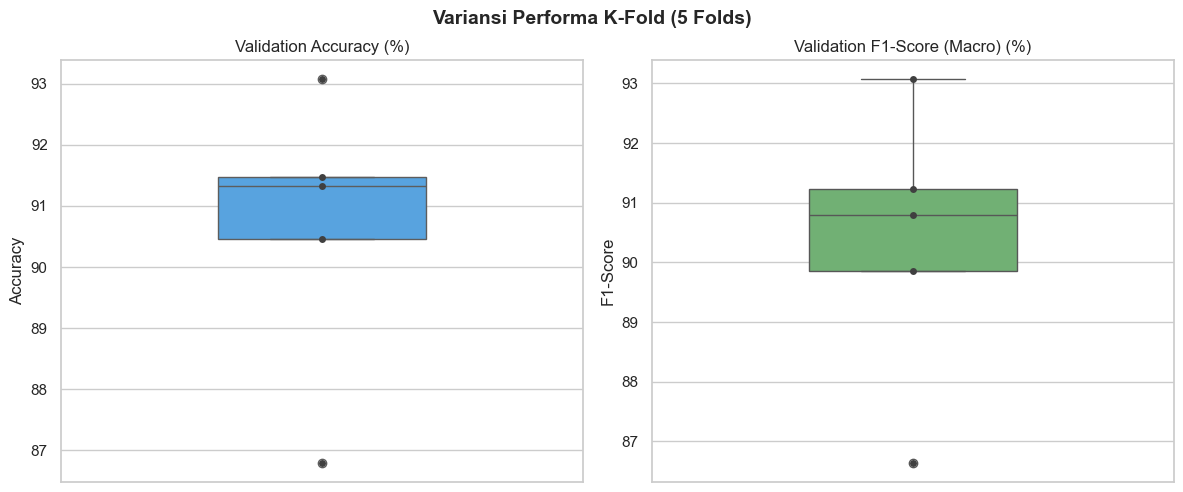

In [19]:
# ============================================================
    # 5. Visualisasi & Laporan Hasil K-Fold
    # ============================================================
end_time = time.time()
mean_acc = np.mean(fold_results_acc)
std_acc = np.std(fold_results_acc)
mean_f1 = np.mean(fold_results_f1)
std_f1 = np.std(fold_results_f1)
    
    # -- Tabel DataFrame --
print(f"\n{'='*65}")
print(f"  Ringkasan Eksekusi [{scenario['name']}]")
print(f"{'='*65}")
print(f"    Waktu Eksekusi : {end_time - start_time:.1f} detik\n")
    
data_kfold = {
    "Fold": [f"Fold {i}" for i in range(1, NUM_FOLDS + 1)] + ["Mean ± Std"],
    "Val Accuracy (%)": [f"{acc*100:.2f}" for acc in fold_results_acc] + [f"{mean_acc*100:.2f} ± {std_acc*100:.2f}"],
    "Val F1-Score (Macro)": [f"{f1*100:.2f}" for f1 in fold_results_f1] + [f"{mean_f1*100:.2f} ± {std_f1*100:.2f}"]
}
df_kfold = pd.DataFrame(data_kfold)
    
# Warna tabel Pandas
display(df_kfold.style.set_properties(**{'background-color': '#F8F9FA', 'color': '#212529', 'border': '1px solid #DEE2E6', 'text-align': 'center'}))
    
# -- Plot Boxplot Variansi K-Fold --
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid", palette="muted")
    
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle(f"Variansi Performa K-Fold ({NUM_FOLDS} Folds)", fontsize=14, fontweight='bold')
    
sns.boxplot(y=np.array(fold_results_acc)*100, ax=axes[0], color="#42A5F5", width=0.4)
sns.swarmplot(y=np.array(fold_results_acc)*100, ax=axes[0], color=".25")
axes[0].set_title("Validation Accuracy (%)")
axes[0].set_ylabel("Accuracy")
    
sns.boxplot(y=np.array(fold_results_f1)*100, ax=axes[1], color="#66BB6A", width=0.4)
sns.swarmplot(y=np.array(fold_results_f1)*100, ax=axes[1], color=".25")
axes[1].set_title("Validation F1-Score (Macro) (%)")
axes[1].set_ylabel("F1-Score")
    
plt.tight_layout()
plt.subplots_adjust(top=0.88)
plt.show()